# Tutorial: Covalent ligand binding with the BEAST-VQE algorithm

In this tutorial, we will learn how to run calculations to describe the bound and unbound states of a ligand binding covalently to a target protein. For this purpose we will use the [BEAST-VQE algorithm](https://qrunch.docs.kvantify.net/docs/explanations/beast.html) available in Kvantify's Qrunch toolkit, which is an approximate quantum algorithm that is intended to scale to large active space sizes. BEAST-VQE uses a paired-electron (or hard-core boson) approximation and thus maps two spatial orbitals to one qubit in contrast to other methods, for example FAST-VQE and similar methods, which map one spatial orbital to two qubits (or one spin orbital to each qubit). Additional benefits are the particularly simple forms of excitation operators and Hamiltonian groups.

More specifically, we are going to take a closer look at [reversible and irreversible covalent inhibition of cathepsin K][article_link]. To that end, we have extracted the data from the article's Supplementary Information, removed the part of the protein for which complete residues were outside of a 10 bohr radius and capped the first alpha carbons outside this radius using hydrogen atoms. The resulting structures have been optimized using [GFN2-xTB](https://xtb-docs.readthedocs.io/en/latest/optimization.html) in an aqueous solution approximated with a continuum model (ALBP). This was done for three of the four ligands and the models are available in "data/large_model". These models are, however, too large for the purposes of this tutorial and a small version, which is roughly equivalent to the QM region of the original paper, is provided in "data/small_model". These models were obtained by manually removing atoms from the large models and running constrained structure optimizations with GFN2-xTB using an implicit water model. Due to the very rough nature of the small models supplied here, it is not recommended to draw conclusions - the data and methodology has been crafted such that the results look reasonable, but probably for the wrong reasons. We will outline in the exercise section how to extend the current script towards solid results.

Of the tree ligands, there is one reversible covalent ligand and two irreversible covalent ligands. The reversible ligand is tagged with _lig01_ while two irreversible ones are tagged with _lig02_ and _lig03_, respectively.

[article_link]: https://pubs.acs.org/doi/10.1021/acs.jcim.2c00466

## Hardware requirements
The basic version of this tutorial, i.e. without the modifications suggested as exercises below, requires at least 16GB of main memory and about 2GB of disk space to run. Furthermore it is recommended to run this on a machine with at least 16 physical cores for the best user experience.

## Setting up the experiment

To prepare the workspace we import the required modules and make a folder where we will store all our results. Also we will set Qrunch to print the most essential logging information, which is useful to track progress in longer-lasting calculations.

In [1]:
from pathlib import Path
import qrunch as qc

output_path = Path("output")
output_path.mkdir(exist_ok=True, parents=True)
qc.setup_logger()

We will start by importing the small molecular models for _lig00_, _lig02_ and _lig03_ for the reactant and product states and store them in two lists for reactant and product configurations, respectively. This will make the code simpler when running the calculations for many configurations and exploring the results.

For the purposes of this tutorial, we rely on [projective embedding theory](https://qrunch.docs.kvantify.net/docs/explanations/projective_embedding.html) to generate the environment through a mean-field approach, while adopting a wave function description of the embedded atoms. The embedded atoms are typically chosen to be the atoms directly involved in a reaction or process of interest.

Importantly, we need to specify a couple of attributes for the systems under consideration, which we will explain in detail. Typically, it is required to set all of these attributes for each individual geometry, but here the structures have many attributes in common - or have been aligned as in the case of the `embedded_atoms` to enable the code as shown below.

- `emedded_atoms`: Here we specify which atoms will be part of the effective Hamiltonian that forms the basis for our BEAST-VQE calculations. All remaining atoms will be part of the effective potential of this Hamiltonian. Note that here we have aligned the structures of the models such that it is always the first three atoms in the xyz files that are the embedded atoms and that the enumeration of the atoms starts with 0.
- `basis_set`: Here we choose the minimal basis set `sto3g` to enable fast execution for the tutorial at the cost of quality of the results. Since we are working with the small models, which are too small for quantitative results, this choice will not make the results much worse.
- `charge`: The supplied small models are neutral. Generally, this has to be verified by looking at the structures - for example, the supplied large models will have a charge of -2.
- `spin_difference`: All models have the same number of alpha and beta electrons, thus the spin difference is 0. This is important, given the fact that we are using the paired electron approximation.

In [2]:
input_path = Path("data/small_model")

embedded_atoms = [0,1,2]
reactant_configurations = []
product_configurations = []

for ligand_id in range(1,4):

    # import ligand reactant state
    reactant_path = input_path / f"lig0{ligand_id}_reduced_reactant.xyz"
    reactant = qc.build_molecular_configuration(reactant_path, basis_set="sto3g", embedded_atoms=embedded_atoms, charge=0, spin_difference=0)
    reactant_configurations.append(reactant)

    # import ligand product state
    product_path = input_path / f"lig0{ligand_id}_reduced_product.xyz"
    product = qc.build_molecular_configuration(product_path, basis_set="sto3g", embedded_atoms=embedded_atoms, charge=0, spin_difference=0)
    product_configurations.append(product)

### Creating the problem with the problem builder

We now come to the core of our problem definition, and where most of the relevant information is provided. 

Importing from our main module, we will use the [fluent build pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html) to construct what we call the `problem_builder_creator`. This object defines what it is that we actually want to calculate for our molecular system, and how we wish to go about it. The philosophy for the usage of the `problem_builder_creator` is one of "narrowing down": we start big, with impactful choices such as picking between a reaction or a single molecular configuration, and then make more and more specific choices about how to handle these configurations.

For the case of this tutorial, the first thing we specify is that we want to calculate `ground_state` energies, meaning that, when we later run the quantum algorithm for our problem, we will try and obtain the lowest energy for each given `molecular_configuration`. Alternatively, we could merge the xyz files for each ligand and regard them as a reaction. This would enable us to import the molecular structures as a `reaction_configuration` and we could use `reaction_path` instead of `ground_state` and simplify some of the remaining code. 

Furthermore, we specify that we would like to run a projective embedding calculation - this way, Qrunch knows it should make use of the earlier specified `embedded_atoms` information.

In [3]:
problem_builder_creator = qc.problem_builder_creator().ground_state().projective_embedding()

In the next steps, we will follow the same pattern which will work whenever we are using a `creator` object. That is, we declare `choose` for a particular step and then specify which method we want to use.
The first choice is of `full_system_solver`: here we pick Density Functional Theory as our mean field method and specify the functional to be `B3LYP`.

In [4]:
dft_options = qc.options.DftCalculatorOptions(functional="b3lyp")
problem_builder_creator = problem_builder_creator.choose_full_system_solver().dft(dft_options)

Next we choose the `orbital_assigner`, which, after orbital localization, assigns orbitals to atoms. We choose the `total_weight` orbital assigner with an assignment tolerance of 0.005. This choice is lower than the default since we are trying to scale to large active space sizes in this tutorial. A higher cutoff leads to fewer orbitals being assigned to the `embedded_atoms` with the consequence that we may not be able to include the desired number of orbitals for some structures. Note that we are using a very small basis set here - for larger basis sets, the default may be good enough.

Another consequence of the lower cutoff is that the construction of the active space becomes more expensive.

In [5]:
problem_builder_creator = problem_builder_creator.choose_orbital_assigner().total_weight(assignment_tolerance=0.005)

We are almost ready to create the `problem_builder`. When considering which part of the system is crucial for our calculations, or what is the size of the quantum space we want to take into account, we have the option to define an active space, which is determined by a number of spatial orbitals and electrons. Any number of orbitals and electrons beyond this choice are considered frozen, and will have a fixed energy. 

The size of the active space will also define how many qubits our system will employ in the quantum algorithm. The active space specifications are added to our reaction builder as a `problem_modifier`. Here, we will consider 26 active spatial orbitals and 26 active electrons. 

Early on, we defined the spin difference as 0 which allows us to run a "restricted" calculation and is necessary for the intended BEAST-VQE calculation. This ensures that the number of alpha and beta electrons assigned to the embedded atoms is the same and the embedded space spin difference will also be 0. The number of beta electrons will be determined automatically by the embedded space spin difference and the specified number of alpha electrons. Thus we can construct the desired (26,26) active space by selecting the numbers as given in the following code cell.

In [6]:
problem_builder_creator = (problem_builder_creator.add_problem_modifier()
        .active_space(
            number_of_active_spatial_orbitals=26,
            number_of_active_alpha_electrons=13,
        )
)

Note - within the BEAST-VQE framework this choice of active space corresponds to 26 qubits and 13 electron pairs.

When running calculations on embedded systems, it is useful to store the mean field results and orbital assignment details so that this information can be reused every time we run energy calculations. For this we can choose a `data_persister_manager`. Below, we first generate a directory where the persister files will be saved, and then pass that as a path to the persister manager:

In [7]:
persister_files = output_path / "persister_data"
persister_files.mkdir(exist_ok=True, parents=True)
problem_builder_creator = problem_builder_creator.choose_data_persister_manager().file_persister(persister_files)

We are now ready to create the `problem_builder`:

In [8]:
problem_builder = problem_builder_creator.create()

And once the builder is set, we are ready to define the problem that we will try and solve with BEAST-VQE . Here, we choose `build_restricted` method as this is required for BEAST-VQE.

This step is where all the embedding and orbital assignment calculations will be performed, and it can take up to 30 minutes for all 6 molecular structures to conclude that calculation on a laptop. The good news is that this needs only to be done once, since the next time the files will be ready in the folder and we simply need to load them!

In [9]:
reactant_problems = [problem_builder.build_restricted(config) for config in reactant_configurations]
product_problems = [problem_builder.build_restricted(config) for config in product_configurations]

## The quantum algorithm

Now, we can turn to defining which quantum algorithm to run and what specifications we desire for it. As previously stated, we will use BEAST-VQE while using standard settings for most parts of the algorithm - you may want to explore various ways of running BEAST-VQE as suggested in the exercises.

A good starting point is to define a `sampler` explicitly which will facilitate moving to quantum hardware at a later point. The `sampler`, as the name suggests, return samples from the state. The state can be a classical simulation of the quantum state or a state encoded on quantum hardware. The main role of the sampler in the algorithm is in performing gate selection.

Note that implicitly the algorithm also uses an `estimator` to estimate the expectation values of the state - since current quantum hardware is generally too noisy to do that, we will use the standard quantum simulator. 

For `sampler` we will rely on the `excitation_gate` simulator, which is Kvantify's proprietary simulator and it allows for very efficient simulation of state vectors with a fixed number of electrons. We may create it and use it in the gate selector as

In [10]:
shots = 1000
sampler = qc.sampler_creator().excitation_gate().with_parallel_setting("parallel").with_total_particle_conservation().create()

With the sampler in hand, we can now set up a calculator using the creator pattern. Some specifics of the setup here are

- We will specify the `last_variable_fft` minimization to avoid potential memory bottlenecks when doing the exercises
- We add the sampler obtained above

In [11]:
calculator = (
    qc.calculator_creator()
    .vqe()
    .iterative()
    .beast()
    .with_gate_selector_sampler(sampler)
    .choose_minimizer()
    .last_variable_fft()
    .create()
)

Now we can call the `calculate` method for the calculator on the different problems we have defined above and wait for the calculation to complete.

In [12]:
reactant_results = [calculator.calculate(problem) for problem in reactant_problems]
product_results = [calculator.calculate(problem) for problem in product_problems]

2025-10-27 13:12:13 [ESSENTIAL] (kvantify.qrunch): Run Adaptive VQE algorithm with 26 qubits:
2025-10-27 13:12:15 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 10: -73.47489558996023
2025-10-27 13:12:15 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 10: -73.50566601143095
2025-10-27 13:12:16 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 10: -73.53157184175288
2025-10-27 13:12:17 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 10: -73.54069246478508
2025-10-27 13:12:18 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 10: -73.55325523846066
2025-10-27 13:12:19 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 10: -73.55977947161749
2025-10-27 13:12:21 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 10: -73.57151493073064
2025-10-27 13:12:22 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 10: -73.57331002745401
2025-10-27 13:12:23 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 10: -73.576

Collect the energies in a convenient format for plotting and print a result table

In [13]:
reactant_energies = [r.total_energy.value for r in reactant_results]
product_energies = [r.total_energy.value for r in product_results]
energy_change = [p - r for p, r in zip(product_energies, reactant_energies)]
energy_change_hf = [p.total_energy_per_macro_iteration_with_initial_energy[0].value - r.total_energy_per_macro_iteration_with_initial_energy[0].value for r, p in zip(reactant_results, product_results)]

print("Ligand  \tReactant Energy (Ha)\tProduct Energy (Ha)\tEnergy Change (Ha)\tEnergy Change HF (Ha)")
labels = ["Ligand 1", "Ligand 2", "Ligand 3"]
for i, ligand in enumerate(labels):
    print(f"{ligand}\t{reactant_energies[i]}\t{product_energies[i]}\t{energy_change[i]}\t{energy_change_hf[i]}")

Ligand  	Reactant Energy (Ha)	Product Energy (Ha)	Energy Change (Ha)	Energy Change HF (Ha)
Ligand 1	-1143.0909677935786	-1143.6674537052916	-0.5764859117130072	-0.5835004200462208
Ligand 2	-1051.6290685457227	-1052.2625701640304	-0.6335016183077187	-0.6486621337814995
Ligand 3	-1090.379433786428	-1090.774724508635	-0.39529072220693706	-0.424455571173894


# Result visualization

Let us start with visualizing the convergence of the individual points to see how efficiently the algorithm converges. Generally for plotting it is convenient to have matplotlib and numpy available

In [14]:
import matplotlib.pyplot as plt
import numpy as np

Now let us plot the convergences for ligand 1 and normalize them with respect to their respective Hartree-Fock contributions, such that we only see the correlation energy that is added in each iteration. You can also switch through the convergences by changing the `ligand_id` in the top of the next code cell and you will find that the reactant electronic structures are typically easier to converge than the product structures.

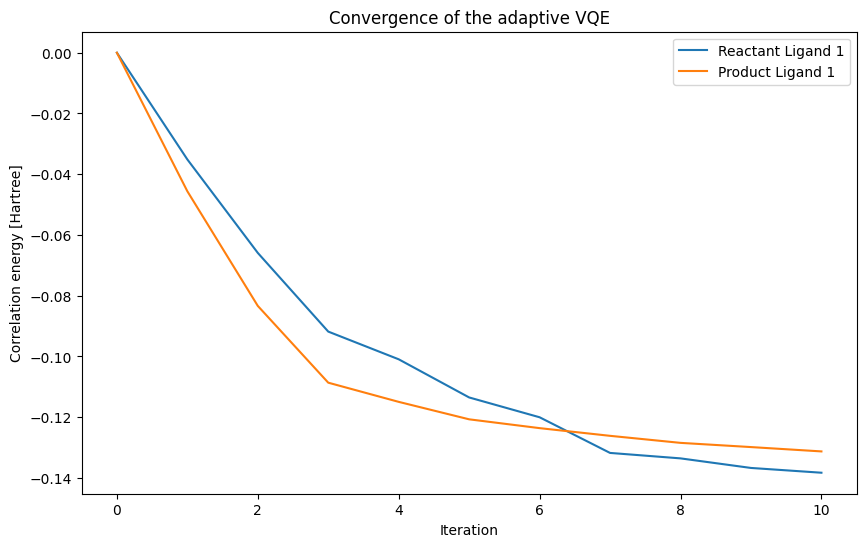

In [15]:
ligand_id = 0

hf_reactant = reactant_results[ligand_id].total_energy_per_macro_iteration_with_initial_energy[0].value
hf_product = product_results[ligand_id].total_energy_per_macro_iteration_with_initial_energy[0].value

conv_data_reactant = np.array(reactant_results[ligand_id].total_energy_per_macro_iteration_with_initial_energy.values) - hf_reactant
conv_data_product = np.array(product_results[ligand_id].total_energy_per_macro_iteration_with_initial_energy.values) - hf_product

conv_fig, conv_ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 6))
conv_ax.plot(conv_data_reactant, label=f"Reactant Ligand {ligand_id+1}")
conv_ax.plot(conv_data_product, label=f"Product Ligand {ligand_id+1}")
conv_ax.set_title("Convergence of the adaptive VQE")
conv_ax.set_xlabel("Iteration")
conv_ax.set_ylabel("Correlation energy [Hartree]")
conv_ax.legend()
plt.show()

Next, we will plot the relative energies (energy differences) between the starting point and the end-point of each reaction to see which reaction product is the most stable. To guide the eye, we add some smooth transition (interpolation with derivatives set to 0) between the two points. You may want to add the corresponding Hartree fock energies here to see how big the correlation contribution is.

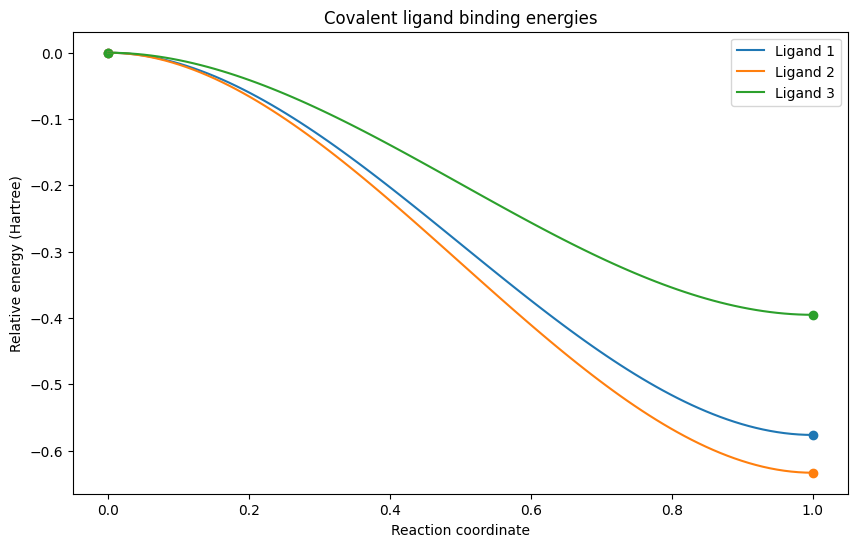

In [16]:
import scipy.interpolate as ip

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 6))

xgrid = np.linspace(0, 1, 100)
for (shifted, shifted_hf, label) in zip(energy_change, energy_change_hf, labels):
    smoother = ip.BPoly.from_derivatives([0.0, 1.0], [[0, 0], [shifted, 0]])
    p = ax.scatter([0, 1], [0, shifted])
    ax.plot(xgrid, smoother(xgrid), label=label, color=p.get_facecolor())

ax.set_ylabel("Relative energy (Hartree)")
ax.set_xlabel("Reaction coordinate")
ax.set_title("Covalent ligand binding energies")
ax.legend()
plt.show()

# Now it is your turn

The main purpose of the following exercises is to extend the above toy model towards more and more realistic calculations with actual quantitative value. To achieve this, a couple of settings, such as check pointing and restart capabilities and various options controlling the behavior and accuracy of the algorithm, are explored such that you can work more efficiently and more accurately with Qrunch. Also we supply some bigger models, which you can try if your computational resources allow you to. 
- Every time we are running the above, we will have to wait for the BEAST-VQE calculation to be run for all structures. This can be slow for large active spaces as we are exploring in this tutorial. One way to improve this is to store intermediate results using the same persister model that we have encountered in the `problem_builder`. Modify the `calculator_creator` with the `choose_data_persister_manager().file_persister` pattern that we have encountered earlier.
- Note from the output that the algorithm did not converge within the predefined number of iterations. Try and go back to the vqe definition and use the `.with_options()` function together with the option definition `qc.options.AdaptiveVqeOptions` to increase the number of iterations until the algorithm successfully converges (see, e.g. the [butyronitrile dissociation tutrial](https://github.com/Kvantify/qdk_tutorials/blob/main/butyronitrile-tutorial/butyronitrile_dissociation.ipynb)). If you are using the file persister model from the previous task you will experience that the BEAST-VQE iterations will simply continue from the stored number of iterations. This can be handy for exploring the convergence properties of the algorithm for various models.
- Try changing the size of the active space, e.g. by making it smaller if you have a small computer and little time, or in the other direction, and look at the convergence plots. What do you see and why is that so? In the context of the persister model, note that new calculations will only be executed if required. For example, the DFT calculation for the full molecule will not be repeated, but everything that has to do with the active space will be recomputed. In this process, Qrunch will make new files, meaning that you can comfortably switch back and forth between the different active space sizes once the data exists.
- Try merging the xyz files for a given ligand and use a `reaction_configuration` instead of the molecular configuration. Several code boxes need to be changed to enable this. Try and make use of the fluent builder pattern and code completion to guide you through the process. 
- Try and use more realistic basis sets, e.g. `pcseg1` or better.
- Try exploring the big models (this can be very heavy). 
- Extend the following code to add transition state information to the reaction plots above. Note that transition state approximations have been supplied for the small models, but not for the large models. Try and plot the convergence pattern of the transition states. What do you observe for the convergence pattern, what do you observe in the reaction profile and why? 
- Moving beyond standard BEAST-VQE. Try running with orbital optimization (`.iterative_with_orbital_optimization`) and compare the convergence patterns and the time used.
- If you want to run on hardware, see for example [the tutorial on calculating ionization potentials](https://github.com/Kvantify/qdk_tutorials/blob/main/ionization-tutorial/ionization_tutorial.ipynb) how this can be done.
 

2025-10-27 13:13:04 [ESSENTIAL] (kvantify.qrunch): Run Adaptive VQE algorithm with 26 qubits:
2025-10-27 13:13:04 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 10: -75.04619965417203
2025-10-27 13:13:04 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 10: -75.07492817764047
2025-10-27 13:13:05 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 10: -75.09570315345825
2025-10-27 13:13:05 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 10: -75.11473224527317
2025-10-27 13:13:06 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 10: -75.12274759999606
2025-10-27 13:13:07 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 10: -75.13427589773521
2025-10-27 13:13:07 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 10: -75.13804606289308
2025-10-27 13:13:08 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 10: -75.1442254999292
2025-10-27 13:13:10 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 10: -75.1470

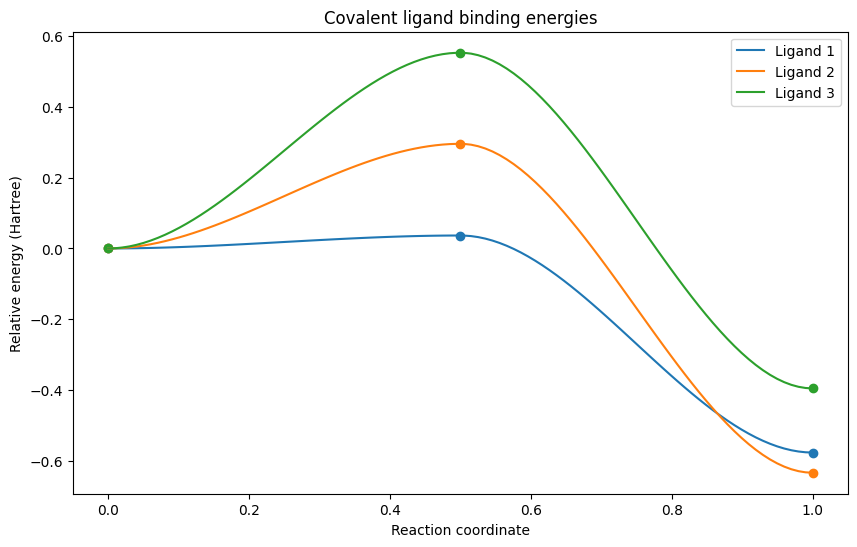

In [ ]:
ts_results = []
for ligand_id in range(1,4):
    ts_path = input_path / f"lig0{ligand_id}_reduced_ts.xyz"

    ...

    ts_result = ...
    ts_results.append(ts_result)

energy_change_ts = [ts.total_energy.value - r.total_energy.value for ts, r in zip(ts_results, reactant_results)]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 6))

for (shifted, shifted_ts, label) in zip(energy_change, energy_change_ts, labels):
    xgrid = np.linspace(0, 1, 100)
    smoother = ip.BPoly.from_derivatives([0.0, 0.5, 1.0], [[0, 0], [shifted_ts, 0], [shifted, 0]])
    p = ax.scatter([0, 0.5, 1], [0, shifted_ts, shifted])
    ax.plot(xgrid, smoother(xgrid), label=label, color=p.get_facecolor())

ax.set_ylabel("Relative energy (Hartree)")
ax.set_xlabel("Reaction coordinate")
ax.set_title("Covalent ligand binding energies")
ax.legend()
plt.show()